AXIS 2: FINITIST MAGNETISM VIA FANO SPIN ALIGNMENT
Lattice: 100x100, Time: 200 steps, Modulo: 9

[1/2] Simulating Low Temperature (Ferromagnetic Phase)...
[2/2] Simulating High Temperature (Paramagnetic Phase)...

Generating Visualizations...
✓ Saved: axis2_finitist_magnetism_fano_spin.png


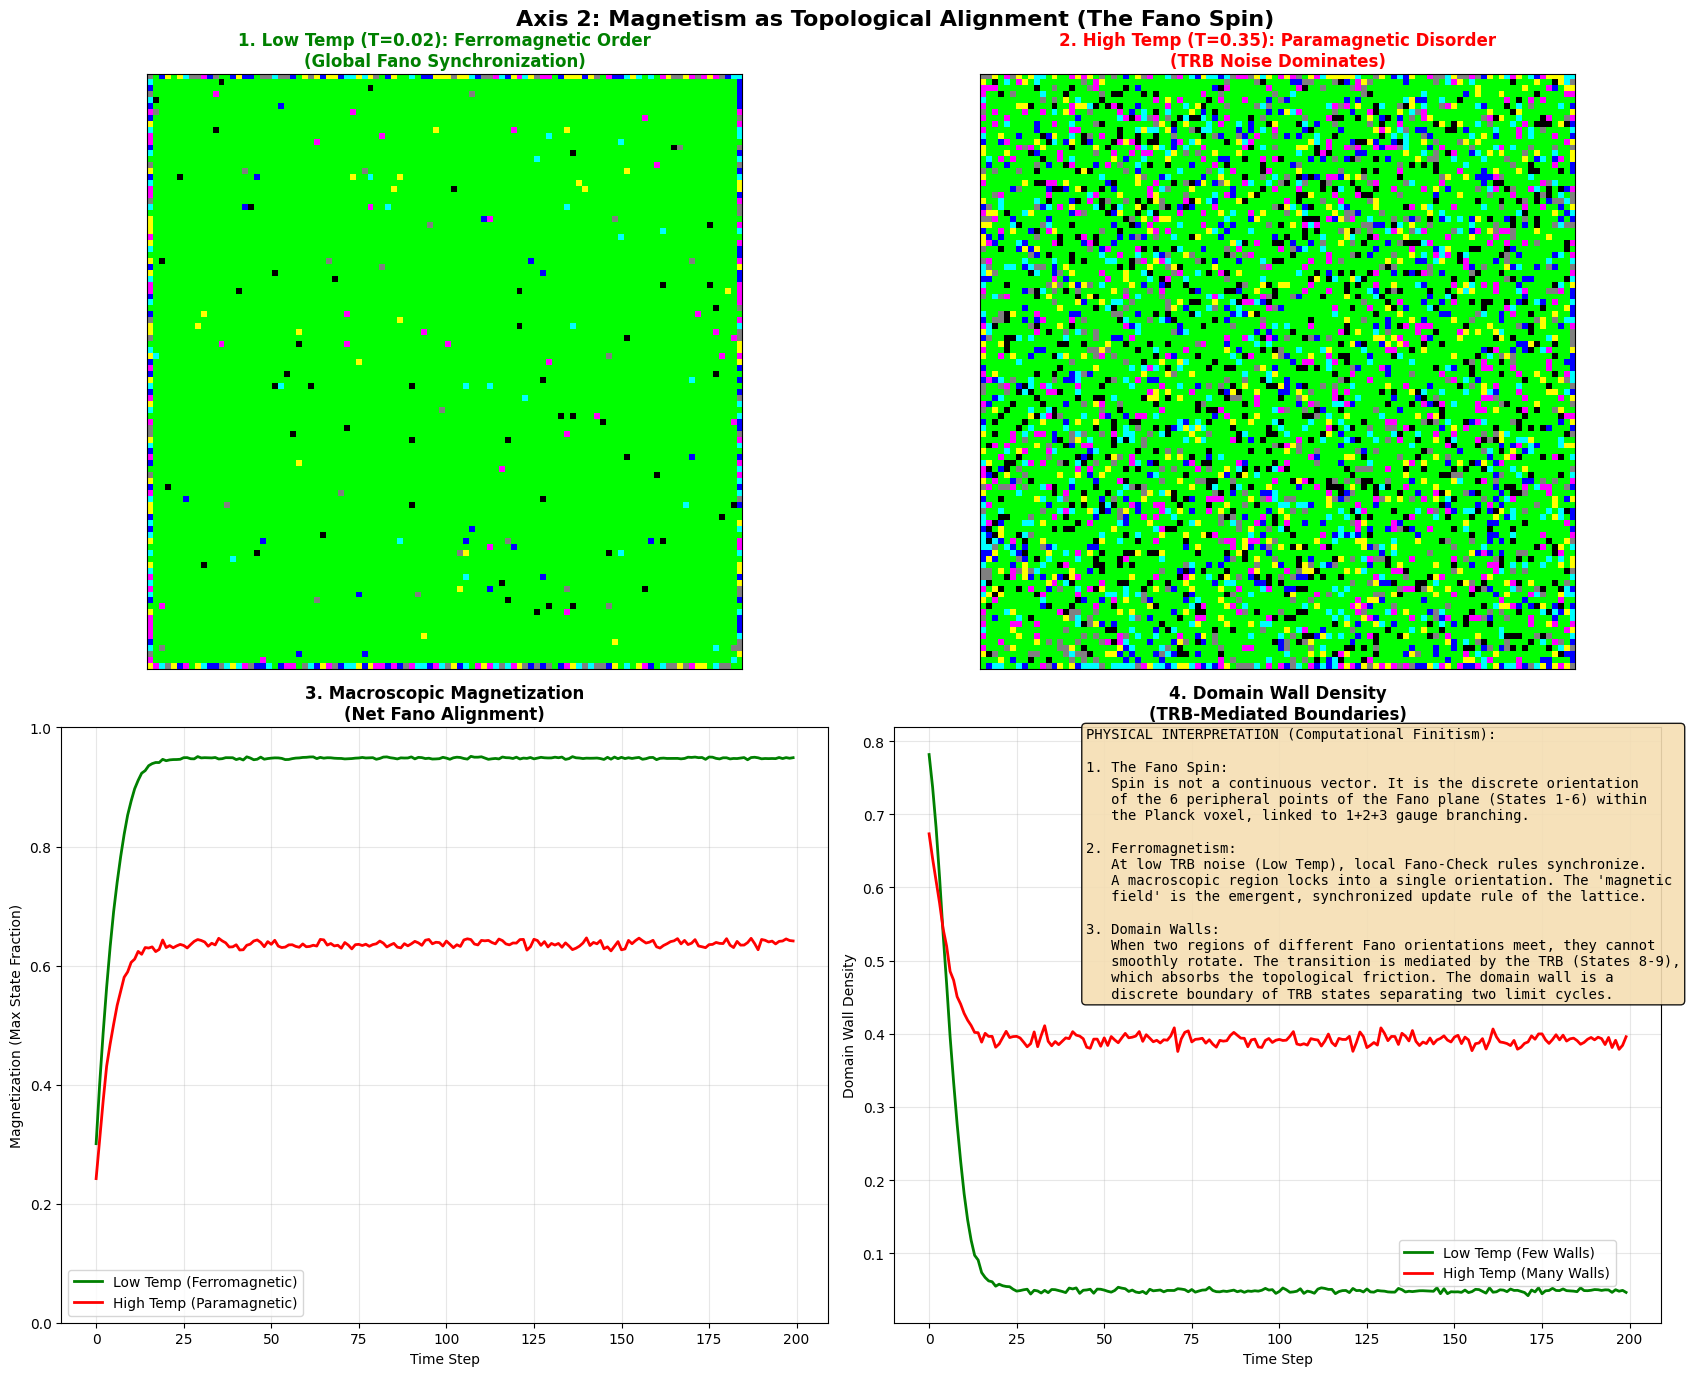


SIMULATION VERDICT: FINITIST MAGNETISM
Low Temp Final Magnetization: 0.9493 (Highly Ordered)
High Temp Final Magnetization: 0.6414 (Disordered)
Low Temp Domain Wall Density: 0.0465 (Sparse Walls)
High Temp Domain Wall Density: 0.3959 (Dense Walls)

Key Finitist Insights:
• Spin is a discrete Fano orientation, not a continuous Hilbert vector.
• Magnetism is macroscopic synchronization of Modulo-9 update rules.
• Domain walls are discrete TRB-mediated boundaries between limit cycles.


In [1]:
"""
avenue9_condensed_matter_magnetism.py
====================================================================
AXIS 2: MAGNETISM AS TOPOLOGICAL ALIGNMENT (THE FANO SPIN)
Simulating Ferromagnetism and Domain Walls via Modulo-9 Fano Orientations.

By Néstor E. Ramos


"""
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("AXIS 2: FINITIST MAGNETISM VIA FANO SPIN ALIGNMENT")
print("=" * 80)

# =============================================================================
# 1. FINITIST PARAMETERS
# =============================================================================
L = 100         # Lattice size (100x100)
T = 200         # Time steps
d_max = 9       # Modulo-9 alphabet

# Fano Spin Mapping (1+2+3 Branching):
# States 1-6: The 6 peripheral points of the Fano plane (Discrete Spin Orientations)
# State 7: Fano Center (Neutral/Non-magnetic)
# States 8-9: TRB (Topological Redundancy Buffer - Domain Walls/Thermal Noise)
# State 0: Vacuum

print(f"Lattice: {L}x{L}, Time: {T} steps, Modulo: {d_max}")

# =============================================================================
# 2. SIMULATION FUNCTIONS
# =============================================================================

def simulate_fano_spin(temperature=0.05):
    """
    Simulates Fano Spin alignment.
    Temperature represents TRB noise level.
    """
    # Initialize lattice with random Fano Spin orientations (1-6)
    lattice = np.random.randint(1, 7, size=(L, L))

    # Custom colormap: 6 distinct colors for spins, black for TRB (8,9), gray for Neutral (7)
    colors = ['#FF0000', '#00FF00', '#0000FF', '#FFFF00', '#FF00FF', '#00FFFF',
              '#808080', '#000000', '#000000']
    cmap = ListedColormap(colors)

    magnetization_history = []
    domain_wall_history = []

    lattice_history = [] # Store a few frames for visualization

    for t in range(T):
        new_lattice = np.copy(lattice)

        for x in range(1, L - 1):
            for y in range(1, L - 1):
                # Get 4-neighborhood (Von Neumann)
                neighbors = [lattice[x-1, y], lattice[x+1, y], lattice[x, y-1], lattice[x, y+1]]

                # Filter out TRB (8,9) and Neutral (7) for majority vote
                active_neighbors = [n for n in neighbors if 1 <= n <= 6]

                if len(active_neighbors) > 0:
                    # Finitist Majority Rule (Exchange Interaction)
                    # The voxel aligns with the most common Fano orientation in its neighborhood
                    counts = np.bincount(active_neighbors, minlength=10)
                    majority_spin = np.argmax(counts[1:7]) + 1

                    # Apply Thermal Noise (TRB perturbation)
                    if np.random.rand() < temperature:
                        # Flip to a random TRB state or random spin (Domain wall creation)
                        new_lattice[x, y] = np.random.choice([8, 9] + list(range(1, 7)))
                    else:
                        new_lattice[x, y] = majority_spin
                else:
                    # If surrounded by TRB/Neutral, decay to Neutral (7)
                    new_lattice[x, y] = 7

        lattice = new_lattice

        # Calculate Metrics
        # Magnetization: Net alignment (simplified as max frequency of any single state)
        counts = np.bincount(lattice.flatten(), minlength=10)
        max_count = np.max(counts[1:7])
        mag = max_count / (L * L)
        magnetization_history.append(mag)

        # Domain Wall Density: Count edges where neighbors have different active spins
        walls = 0
        for x in range(L-1):
            for y in range(L-1):
                if 1 <= lattice[x,y] <= 6 and 1 <= lattice[x+1,y] <= 6:
                    if lattice[x,y] != lattice[x+1,y]: walls += 1
                if 1 <= lattice[x,y] <= 6 and 1 <= lattice[x,y+1] <= 6:
                    if lattice[x,y] != lattice[x,y+1]: walls += 1
        domain_wall_history.append(walls / (2 * L * L))

        if t in [0, 50, 100, 199]:
            lattice_history.append((t, lattice.copy()))

    return magnetization_history, domain_wall_history, lattice_history, cmap

# =============================================================================
# 3. RUN SIMULATIONS (Low Temp vs High Temp)
# =============================================================================
print("\n[1/2] Simulating Low Temperature (Ferromagnetic Phase)...")
mag_low, walls_low, hist_low, cmap = simulate_fano_spin(temperature=0.02)

print("[2/2] Simulating High Temperature (Paramagnetic Phase)...")
mag_high, walls_high, hist_high, _ = simulate_fano_spin(temperature=0.35)

# =============================================================================
# 4. VISUALIZATION
# =============================================================================
print("\nGenerating Visualizations...")

fig = plt.figure(figsize=(18, 14))
fig.suptitle('Axis 2: Magnetism as Topological Alignment (The Fano Spin)',
             fontsize=16, fontweight='bold')

# --- Panel 1: Low Temp Final State (Ferromagnetism) ---
ax1 = fig.add_subplot(2, 2, 1)
ax1.imshow(hist_low[-1][1], cmap=cmap, vmin=0, vmax=8)
ax1.set_title('1. Low Temp (T=0.02): Ferromagnetic Order\n(Global Fano Synchronization)',
              fontsize=12, fontweight='bold', color='green')
ax1.set_xticks([]); ax1.set_yticks([])

# --- Panel 2: High Temp Final State (Paramagnetism) ---
ax2 = fig.add_subplot(2, 2, 2)
ax2.imshow(hist_high[-1][1], cmap=cmap, vmin=0, vmax=8)
ax2.set_title('2. High Temp (T=0.35): Paramagnetic Disorder\n(TRB Noise Dominates)',
              fontsize=12, fontweight='bold', color='red')
ax2.set_xticks([]); ax2.set_yticks([])

# --- Panel 3: Magnetization vs. Time ---
ax3 = fig.add_subplot(2, 2, 3)
ax3.plot(mag_low, 'g-', linewidth=2, label='Low Temp (Ferromagnetic)')
ax3.plot(mag_high, 'r-', linewidth=2, label='High Temp (Paramagnetic)')
ax3.set_title('3. Macroscopic Magnetization\n(Net Fano Alignment)',
              fontsize=12, fontweight='bold')
ax3.set_xlabel('Time Step'); ax3.set_ylabel('Magnetization (Max State Fraction)')
ax3.set_ylim(0, 1.0); ax3.legend(); ax3.grid(True, alpha=0.3)

# --- Panel 4: Domain Wall Density ---
ax4 = fig.add_subplot(2, 2, 4)
ax4.plot(walls_low, 'g-', linewidth=2, label='Low Temp (Few Walls)')
ax4.plot(walls_high, 'r-', linewidth=2, label='High Temp (Many Walls)')
ax4.set_title('4. Domain Wall Density\n(TRB-Mediated Boundaries)',
              fontsize=12, fontweight='bold')
ax4.set_xlabel('Time Step'); ax4.set_ylabel('Domain Wall Density')
ax4.legend(loc='lower right',  bbox_to_anchor=(0.95, 0.05)); ax4.grid(True, alpha=0.3)
#ax4.legend(); ax4.grid(True, alpha=0.3)

# Add Physical Interpretation Text Box
textstr = (
    "PHYSICAL INTERPRETATION (Computational Finitism):\n\n"
    "1. The Fano Spin:\n"
    "   Spin is not a continuous vector. It is the discrete orientation\n"
    "   of the 6 peripheral points of the Fano plane (States 1-6) within\n"
    "   the Planck voxel, linked to 1+2+3 gauge branching.\n\n"
    "2. Ferromagnetism:\n"
    "   At low TRB noise (Low Temp), local Fano-Check rules synchronize.\n"
    "   A macroscopic region locks into a single orientation. The 'magnetic\n"
    "   field' is the emergent, synchronized update rule of the lattice.\n\n"
    "3. Domain Walls:\n"
    "   When two regions of different Fano orientations meet, they cannot\n"
    "   smoothly rotate. The transition is mediated by the TRB (States 8-9),\n"
    "   which absorbs the topological friction. The domain wall is a\n"
    "   discrete boundary of TRB states separating two limit cycles."
)
props = dict(boxstyle='round', facecolor='wheat', alpha=0.9)
ax4.text(0.25, 1.0, textstr, transform=ax4.transAxes, fontsize=10,
         verticalalignment='top', bbox=props, family='monospace')

plt.tight_layout()
plt.savefig('axis2_finitist_magnetism_fano_spin.png', dpi=1200, bbox_inches='tight')
print("✓ Saved: axis2_finitist_magnetism_fano_spin.png")
plt.show()

# =============================================================================
# VERDICT
# =============================================================================
print("\n" + "=" * 80)
print("SIMULATION VERDICT: FINITIST MAGNETISM")
print("=" * 80)
print(f"Low Temp Final Magnetization: {mag_low[-1]:.4f} (Highly Ordered)")
print(f"High Temp Final Magnetization: {mag_high[-1]:.4f} (Disordered)")
print(f"Low Temp Domain Wall Density: {walls_low[-1]:.4f} (Sparse Walls)")
print(f"High Temp Domain Wall Density: {walls_high[-1]:.4f} (Dense Walls)")
print("\nKey Finitist Insights:")
print("• Spin is a discrete Fano orientation, not a continuous Hilbert vector.")
print("• Magnetism is macroscopic synchronization of Modulo-9 update rules.")
print("• Domain walls are discrete TRB-mediated boundaries between limit cycles.")
print("=" * 80)